In [1]:
import numpy as np
from scipy.ndimage import shift, affine_transform
from scipy.optimize import minimize
import matplotlib.pyplot as plt
from astropy.io import fits

In [2]:
import specula
specula.init(0)
from specula.data_objects.ifunc import IFunc

2026-10-10 15:59:19,675 [INFO]: [specula]: Cupy import successfull. Installed version is: 13.3.0
2026-10-10 15:59:19,949 [INFO]: [specula]: Default device is GPU number 0


In [3]:
import matplotlib as mpl
from cycler import cycler

cmap = mpl.colormaps['hot'] # 1. Choose your colormap (e.g., 'hot', 'jet', 'turbo')
colors = cmap(np.linspace(0.0, 1.0, 7)) # 2. Extract a set of colors from it (e.g., 6 distinct colors across the map)
plt.rcParams['axes.prop_cycle'] = cycler(color=colors) # 3. Apply it to the default line cycle
plt.rcParams['image.cmap'] = 'hot' # 4. Change the default colormap for images/scatter plots
plt.rcParams.update({
    "text.usetex": True, # Use LaTeX to write all text
    "font.family": "serif", # Use a serif font
    "font.serif": ["Computer Modern Roman"] # Specifically use the classic LaTeX font
})
plt.rcParams['image.origin'] = 'lower'

In [4]:

def compute_actuator_pitch(mask_shape: tuple, n_acts: int) -> float:
    """Estimates actuator pitch for a circular grid: dim / sqrt(4 * n_acts / pi)."""
    dim = max(mask_shape)
    return dim / np.sqrt(4.0 * n_acts / np.pi)


def estimate_actuator_peaks(ifs: np.ndarray, mask: np.ndarray = None, subpixel: bool = True) -> np.ndarray:
    """Estimates (y, x) peak coordinates for each influence function in its native grid."""
    n_acts, h, w = ifs.shape
    coords = np.zeros((n_acts, 2))  # Stored as [y, x]
    
    for i in range(n_acts):
        img = np.abs(ifs[i]) * (mask if mask is not None else 1.0)
        max_val = np.max(img)
        
        if max_val < 1e-12:
            coords[i] = [np.nan, np.nan]
            continue
            
        max_idx = np.unravel_index(np.argmax(img), img.shape)
        py, px = max_idx[0], max_idx[1]
        
        if subpixel and 1 <= py < h - 1 and 1 <= px < w - 1:
            dx = (img[py, px + 1] - img[py, px - 1]) / (2.0 * (2.0 * img[py, px] - img[py, px + 1] - img[py, px - 1] + 1e-12))
            dy = (img[py + 1, px] - img[py - 1, px]) / (2.0 * (2.0 * img[py, px] - img[py + 1, px] - img[py - 1, px] + 1e-12))
            coords[i] = [py + np.clip(dy, -0.5, 0.5), px + np.clip(dx, -0.5, 0.5)]
        else:
            coords[i] = [float(py), float(px)]
            
    return coords


def identify_inner_actuators_radial(coords: np.ndarray, mask_shape: tuple, pitch: float, n_outer_rings: int = 2) -> np.ndarray:
    """Identifies inner actuators using radial distance from grid center."""
    valid_mask = ~np.isnan(coords[:, 0])
    cy, cx = mask_shape[0] / 2.0, mask_shape[1] / 2.0
    
    radii = np.full(len(coords), np.inf)
    radii[valid_mask] = np.sqrt((coords[valid_mask, 0] - cy)**2 + (coords[valid_mask, 1] - cx)**2)
    
    max_radius = np.max(radii[valid_mask])
    threshold_radius = max_radius - (n_outer_rings - 0.5) * pitch
    
    return (radii < threshold_radius) & valid_mask

def fit_similarity_transform(src_pts: np.ndarray, dst_pts: np.ndarray):
    """Computes global similarity transformation (Scale, Rotation, Shift) mapping src -> dst."""
    src_centroid = np.mean(src_pts, axis=0)  # [cy, cx]
    dst_centroid = np.mean(dst_pts, axis=0)  # [cy, cx]
    
    src_centered = src_pts - src_centroid
    dst_centered = dst_pts - dst_centroid
    
    H = src_centered.T @ dst_centered
    U, S, Vt = np.linalg.svd(H)
    R = Vt.T @ U.T
    
    if np.linalg.det(R) < 0:
        Vt[-1, :] *= -1
        R = Vt.T @ U.T
        
    scale = np.sum(S) / np.sum(src_centered**2)
    t_y_x = dst_centroid - scale * (R @ src_centroid)
    
    return scale, R, t_y_x


def apply_global_registration_to_ifs(sim_ifs: np.ndarray, scale: float, R: np.ndarray, t_y_x: np.ndarray, target_shape: tuple) -> np.ndarray:
    """Warps simulated IFs into the measured grid frame [y, x]."""
    n_acts = len(sim_ifs)
    reg_sim_ifs = np.zeros((n_acts, *target_shape))
    
    inv_R = R.T / scale
    inv_t = -inv_R @ t_y_x
    
    for i in range(n_acts):
        reg_sim_ifs[i] = affine_transform(
            sim_ifs[i], 
            matrix=inv_R, 
            offset=inv_t,
            output_shape=target_shape, 
            order=3
        )
    return reg_sim_ifs


def transform_coordinates(coords: np.ndarray, scale: float, R: np.ndarray, t_y_x: np.ndarray) -> np.ndarray:
    """Applies global similarity transformation directly to [y, x] coordinate array."""
    return scale * (coords @ R.T) + t_y_x


def _refine_actuator_shift(
    meas_img: np.ndarray,
    sim_img: np.ndarray,
    py: int,
    px: int,
    window: int,
    max_shift: float,
    pad: int = 4,
):
    """
    Refines the local (dy, dx) sub-pixel shift of one simulated IF against its
    measured counterpart, using a small padded crop instead of shifting the
    full-frame image on every optimizer evaluation. Amplitude is solved in
    closed form (linear least squares) for each trial (dy, dx), so the
    optimizer only searches a 2D space.

    Returns (dy_opt, dx_opt, amp_opt) or None if the crop has no signal.
    """
    h, w = sim_img.shape
    y_min, y_max = max(0, py - window), min(h, py + window)
    x_min, x_max = max(0, px - window), min(w, px + window)

    meas_crop = meas_img[y_min:y_max, x_min:x_max]

    # Padded region so the shifted crop doesn't need samples outside it
    y0, y1 = max(0, y_min - pad), min(h, y_max + pad)
    x0, x1 = max(0, x_min - pad), min(w, x_max + pad)
    sim_pad = sim_img[y0:y1, x0:x1]
    sim_crop0 = sim_img[y_min:y_max, x_min:x_max]

    if np.max(np.abs(meas_crop)) <= 1e-12 or np.max(np.abs(sim_crop0)) <= 1e-12:
        return None

    # Local slice of the padded crop that corresponds to (y_min:y_max, x_min:x_max)
    sl_y = slice(y_min - y0, y_max - y0)
    sl_x = slice(x_min - x0, x_max - x0)

    def shifted_crop(dy, dx):
        return shift(sim_pad, shift=[dy, dx], order=3)[sl_y, sl_x]

    def loss(params):
        dy, dx = params
        crop = shifted_crop(dy, dx)
        denom = np.sum(crop**2) + 1e-12
        amp = np.sum(meas_crop * crop) / denom  # closed-form optimal amplitude
        return np.sum((meas_crop - amp * crop)**2)

    res = minimize(
        loss,
        x0=[0.0, 0.0],
        bounds=[(-max_shift, max_shift), (-max_shift, max_shift)],
        method='L-BFGS-B'
    )

    dy_opt, dx_opt = res.x
    final_crop = shifted_crop(dy_opt, dx_opt)
    denom = np.sum(final_crop**2) + 1e-12
    amp_opt = np.sum(meas_crop * final_crop) / denom

    return dy_opt, dx_opt, amp_opt


def fit_amplitudes_to_sim_ifs(
    meas_ifs: np.ndarray, 
    meas_mask: np.ndarray, 
    sim_ifs_registered: np.ndarray, 
    reg_param: float = 1e-2,
    optimize_coords: bool = True,
):
    """
    Fits measured IFs to registered simulated IFs, with optional per-actuator
    sub-pixel coordinate refinement.

    The coordinate refinement (phase 1) is independent across actuators -
    each simulated IF is only ever compared to its own measured counterpart,
    so it's decoupled from a global solve rather than being interleaved with
    one. The amplitude/coupling fit (phase 2) is then done once, for all
    actuators simultaneously, via a single batched linear solve instead of
    an explicit-inverse solver rebuilt on every iteration.

    Returns:
        amplitude_matrix: (N_acts, N_acts) array of coupling weights.
        scaled_sim_ifs: (N_acts, H, W) array of the final reconstructed IFs.
    """
    n_acts, h, w = meas_ifs.shape
    valid_mask = meas_mask > 0

    updated_sim_ifs = np.copy(sim_ifs_registered)

    # Estimate actuator pitch for shift constraints
    pitch = max(h, w) / np.sqrt(4.0 * n_acts / np.pi)
    max_shift = 0.5 * pitch
    window = int(pitch)

    # --- Phase 1: per-actuator sub-pixel shift refinement (independent, no
    # global solve needed here) ---
    if optimize_coords:
        print("Starting per-actuator coordinate refinement...")
        for idx in range(n_acts):
            meas_img = meas_ifs[idx]
            sim_img = updated_sim_ifs[idx]

            py, px = np.unravel_index(np.argmax(np.abs(sim_img)), (h, w))
            result = _refine_actuator_shift(meas_img, sim_img, py, px, window, max_shift)
            if result is None:
                continue

            dy_opt, dx_opt, amp_opt = result
            # dy/dx are bounded independently, so compare each axis to
            # max_shift rather than the combined magnitude (a diagonal shift
            # can legitimately reach up to sqrt(2) * max_shift).
            if max(abs(dy_opt), abs(dx_opt)) > 1e-3:
                print(f'Act {idx}: [{dx_opt:.3f}, {dy_opt:.3f}] pix')
                updated_sim_ifs[idx] = shift(sim_img, shift=[dy_opt, dx_opt], order=3)

    # --- Phase 2: single batched linear solve for all actuators' amplitudes ---
    print("Solving for amplitude/coupling matrix...")
    S_fit = updated_sim_ifs[:, valid_mask]           # (n_acts, n_pixels)
    meas_fit = meas_ifs[:, valid_mask]                # (n_acts, n_pixels)

    StS = S_fit @ S_fit.T                             # (n_acts, n_acts)
    # reg_I = reg_param * np.eye(n_acts) * (np.trace(StS) / n_acts)
    rhs = S_fit @ meas_fit.T                          # (n_acts, n_acts)

    # # solve (StS + reg_I) @ X = rhs for X, then transpose so row i holds the
    # # amplitude vector for measured actuator i (avoids forming an explicit
    # # inverse, both faster and better conditioned)
    # amplitude_matrix = np.linalg.solve(StS + reg_I, rhs).T
    StSinv = np.linalg.pinv(StS,rcond=reg_param)
    amplitude_matrix = (StSinv @ rhs).T
    amplitude_matrix -= amplitude_matrix.mean(axis=1, keepdims=True)

    # Reconstruct the final scaled IFs across the FULL domain using the updated basis
    scaled_sim_ifs = np.einsum('ij,jhw->ihw', amplitude_matrix, updated_sim_ifs)

    return amplitude_matrix, scaled_sim_ifs


def plot_results(meas_ifs: np.ndarray, sim_ifs: np.ndarray, pupil_center: tuple, pupil_radius: float, coords: np.ndarray):
    """Displays measured IFs, registered simulated IFs, and the Nact x Nact TPS amplitude matrix."""
    
    norm_meas = (meas_ifs - np.mean(meas_ifs[abs(meas_ifs)>0])) / np.max(np.abs(meas_ifs))
    norm_sim = (sim_ifs - np.mean(sim_ifs[abs(sim_ifs)>0]))/ np.max(np.abs(sim_ifs))
    diff = np.sqrt(np.sum((norm_meas-norm_sim)**2,axis=0))
    
    sum_meas = np.sum(np.abs(norm_meas)**3, axis=0)
    sum_sim = np.sum(np.abs(norm_sim)**3, axis=0)
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        
    im0 = axes[0].imshow(sum_meas, cmap='viridis', origin='lower',vmin=0,vmax=1.5)
    axes[0].set_title("Sum of cubed MEASURED iffs")
    axes[0].axis('off')
    fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)
    
    im1 = axes[1].imshow(sum_sim, cmap='viridis', origin='lower',vmin=0,vmax=1.5)
    axes[1].set_title("Sum of cubed SIMULATED iffs")
    axes[1].axis('off')
    fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

    im2 = axes[2].imshow(diff * (np.sum(abs(meas_ifs),axis=0)>0), cmap='RdBu', origin='lower')
    axes[2].plot(coords[:,1],coords[:,0],'.',markersize=2,c='gray',alpha=0.5,label='act coords')
    axes[2].set_title("Difference RSS")
    axes[2].axis('off')
    fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)
    
    # Add pupil rims
    for ax in axes:
        circle = plt.Circle(pupil_center, pupil_radius, color='red', fill=False, linestyle='--', linewidth=1.5, alpha=0.8, label='Pupil Rim')
        ax.add_patch(circle)
        ax.legend(loc='upper right')
    
    plt.tight_layout()
    plt.show()


def register_ao_ifs(
    meas_ifs: np.ndarray, 
    meas_mask: np.ndarray, 
    sim_ifs: np.ndarray, 
    sim_mask: np.ndarray,
    n_outer_rings: int = 2,
    show_plots: bool = True,
    optimize_coords: bool = False
):
    print("\n--- Starting Simplified AO Influence Function Calibration ---")
    
    n_acts = sim_ifs.shape[0]
    pitch_sim = compute_actuator_pitch(sim_mask.shape, n_acts)
    
    meas_cy, meas_cx = meas_mask.shape[0] / 2.0, meas_mask.shape[1] / 2.0
    orig_pupil_center = (meas_cx, meas_cy)
    y_idx, x_idx = np.where(meas_mask > 0)
    orig_pupil_radius = np.max(np.sqrt((x_idx - meas_cx)**2 + (y_idx - meas_cy)**2)) if len(y_idx) > 0 else 0.0
    
    print("1. Estimating actuator peak positions on native grids [y, x]...")
    coords_meas = estimate_actuator_peaks(meas_ifs, meas_mask)
    coords_sim = estimate_actuator_peaks(sim_ifs, sim_mask)
    
    print(f"2. Identifying inner actuators (excluding outer {n_outer_rings} ring(s))...")
    inner_mask = identify_inner_actuators_radial(coords_sim, mask_shape=sim_mask.shape, pitch=pitch_sim, n_outer_rings=n_outer_rings)
    
    print("3. Computing global registration parameters (Scale, Rotation, Shift)...")
    scale, R, t_y_x = fit_similarity_transform(coords_sim[inner_mask], coords_meas[inner_mask])
    rotInDeg = np.arctan2(-R[0,1],R[0,0])*180/np.pi
    print(f'-> Scale: {scale:1.4f}, Rotation: {rotInDeg:1.1f}°, Shift [dx,dy]: [{t_y_x[0]:1.2f},{t_y_x[1]:1.2f}] pix')
    
    print("4. Registering simulated IFs and center coordinates...")
    target_shape = meas_ifs.shape[1:]
    sim_ifs_registered = apply_global_registration_to_ifs(sim_ifs, scale, R, t_y_x, target_shape)
    reg_coords_sim = transform_coordinates(coords_sim, scale, R, t_y_x)

    if show_plots:
        plot_results(meas_ifs, sim_ifs_registered, orig_pupil_center, orig_pupil_radius, reg_coords_sim)
    
    print("5. Computing TPS amplitude matrix across all degrees of freedom...")
    # amplitude_matrix, sim_ifs_registered_rescaled = fit_tps_amplitude_matrix(meas_ifs, meas_mask, reg_coords_sim)
    amplitude_matrix, scaled_sim_ifs = fit_amplitudes_to_sim_ifs(meas_ifs, meas_mask, sim_ifs_registered, optimize_coords=optimize_coords)
    
    print("--- Calibration Complete! ---\n")
    
    if show_plots:
        plot_results(meas_ifs, scaled_sim_ifs, orig_pupil_center, orig_pupil_radius, reg_coords_sim)
        plt.figure()
        plt.imshow(amplitude_matrix,cmap='magma')
        plt.colorbar()
        plt.title('Actuator displacements matrix')
        
    return scaled_sim_ifs, amplitude_matrix, reg_coords_sim


In [5]:
def reshape3d(ifs,mask):
    ifs2use = ifs.copy() if ifs.shape[0]<ifs.shape[1] else ifs.T
    mask2use = mask.astype(bool) if np.sum(mask) == ifs2use.shape[1] else (1-mask).astype(bool)

    ifs2use -= np.median(ifs2use,axis=1)[:,None]

    nActs = np.shape(ifs2use)[0]
    ifs2d = np.zeros([nActs,mask.shape[0],mask.shape[1]])
    for j in range(nActs):
        img = np.zeros(mask.shape).flatten()
        img[mask.astype(bool).flatten()] = ifs2use[j]
        ifs2d[j] = img.reshape(mask.shape)
    return ifs2d, mask2use

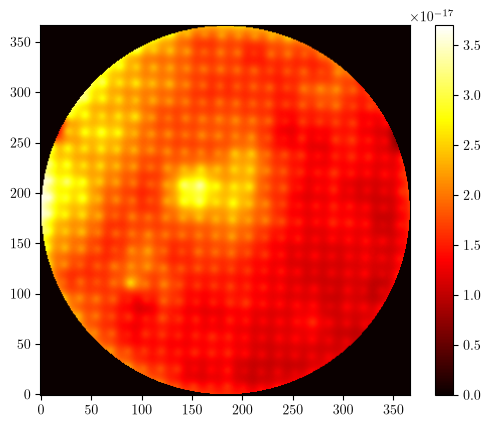

In [6]:


# Simulated IFs
# sim_iffs = fits.getdata('/raid1/mmenessini/calibration/EKARUS/ifunc/dm468_367pix_ifunc.fits')
# sim_mask = fits.getdata('/raid1/mmenessini/calibration/EKARUS/pupilstop/dm468_367pix_pupil.fits')
sim_iffs = fits.getdata('/raid1/mmenessini/calibration/EKARUS/ifunc/dm468_400pix_ifunc.fits')
sim_mask = fits.getdata('/raid1/mmenessini/calibration/EKARUS/pupilstop/dm468_400pix_pupil.fits')
# sim_iffs = fits.getdata('/raid1/mmenessini/calibration/Cascading/ifunc/dm820_420pix_ifunc.fits')
# sim_mask = fits.getdata('/raid1/mmenessini/calibration/Cascading/pupilstop/dm820_420pix_pupil.fits')

# Measured IFs
meas_iffs = fits.getdata('/raid1/mmenessini/calibration/EKARUS/data/reordered_DM468_iffs.fits')
meas_mask = (fits.getdata('/raid1/mmenessini/calibration/EKARUS/pupilstop/reordered_DM468_367pixels.fits')).astype(bool)
# meas_iffs = fits.getdata('/raid1/mmenessini/calibration/Cascading/data/20260831_142915_iffs.fits')
# meas_mask = (fits.getdata('/raid1/mmenessini/calibration/Cascading/data/20260831_142915_mask_crop.fits')).astype(bool)

# print(np.mean(meas_iffs.T,axis=1).shape,meas_iffs.shape)

meas_ifs2d, meas_mask = reshape3d(meas_iffs, meas_mask)
plt.figure()
plt.imshow(np.sum(abs(meas_ifs2d)**3,axis=0),origin='lower')
plt.colorbar()

sim_ifs2d, sim_mask = reshape3d(sim_iffs, sim_mask)
sim_iffs_flip = np.zeros_like(sim_iffs)
for i in range(len(sim_ifs2d)):
    sim_iffs_flip[:,i] = np.flipud(sim_ifs2d[i])[sim_mask]
    # sim_iffs_flip[:,i] = np.fliplr(np.flipud(sim_ifs2d[i]))[sim_mask]

# print(sim_iffs.shape)

sim_ifs2d_flip, sim_mask = reshape3d(sim_iffs_flip, sim_mask)

In [7]:
# plt.figure()
# plt.plot(np.std(sim_iffs,axis=0)*6e-6)
# plt.plot(np.std(meas_iffs,axis=0))
# plt.grid()

# fits.writeto('/raid1/mmenessini/calibration/Cascading/data/dm820_sym_iffs_flipped.fits',(sim_iffs_flip*6e-6).astype(np.float32).T,overwrite=True)

In [8]:
# flip_mask = np.fliplr(np.flipud(sim_mask))
# fits.writeto('/raid1/mmenessini/calibration/Cascading/data/dm820_sym_iffs_mask_flipped.fits',flip_mask.astype(np.uint8),overwrite=True)

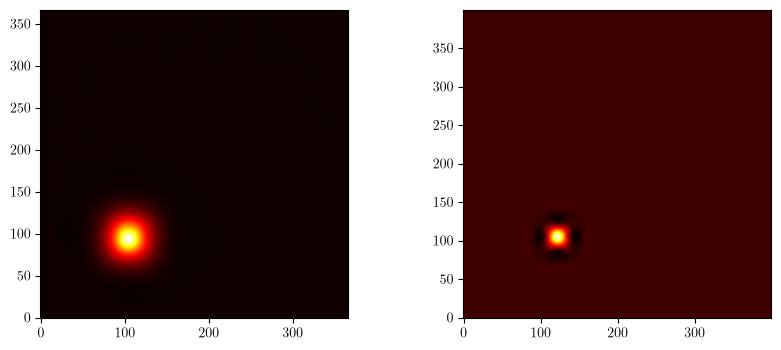

In [9]:
idx = 100

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(meas_ifs2d[idx],origin='lower')
plt.subplot(1,2,2)
plt.imshow(sim_ifs2d_flip[idx],origin='lower')


--- Starting Simplified AO Influence Function Calibration ---
1. Estimating actuator peak positions on native grids [y, x]...
2. Identifying inner actuators (excluding outer 2 ring(s))...
3. Computing global registration parameters (Scale, Rotation, Shift)...
-> Scale: 0.9659, Rotation: 1.7°, Shift [dx,dy]: [-4.85,-16.27] pix
4. Registering simulated IFs and center coordinates...


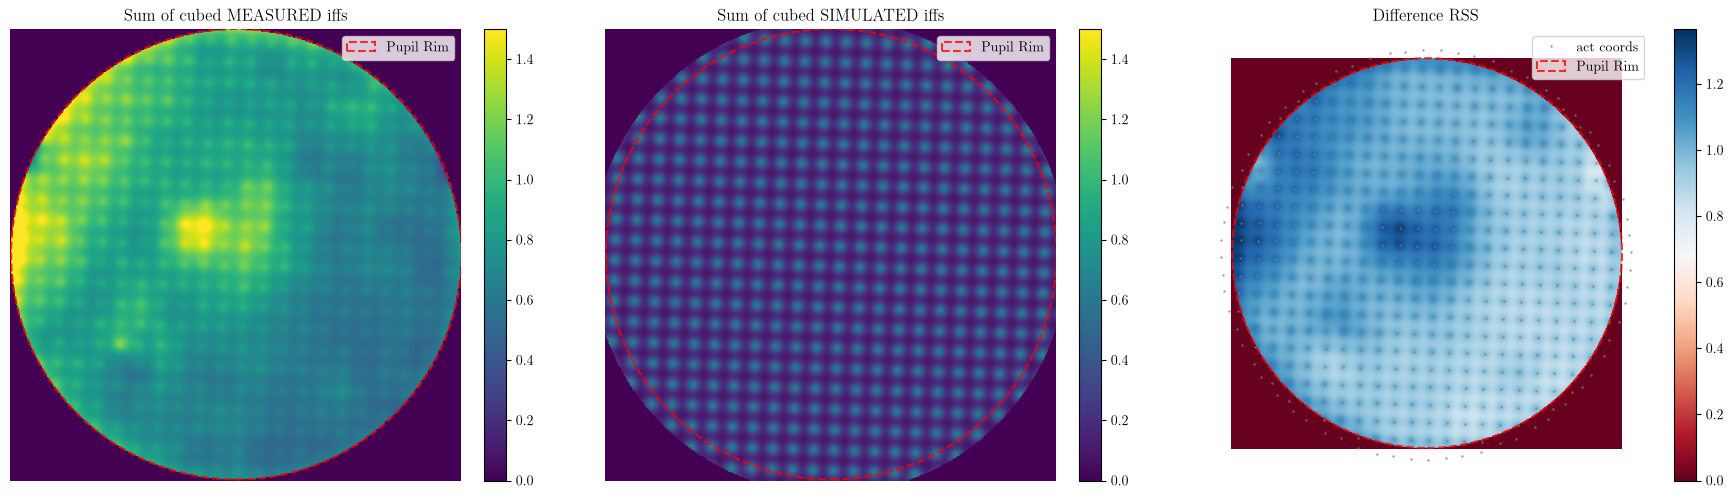

5. Computing TPS amplitude matrix across all degrees of freedom...
Starting per-actuator coordinate refinement...
Solving for amplitude/coupling matrix...
--- Calibration Complete! ---



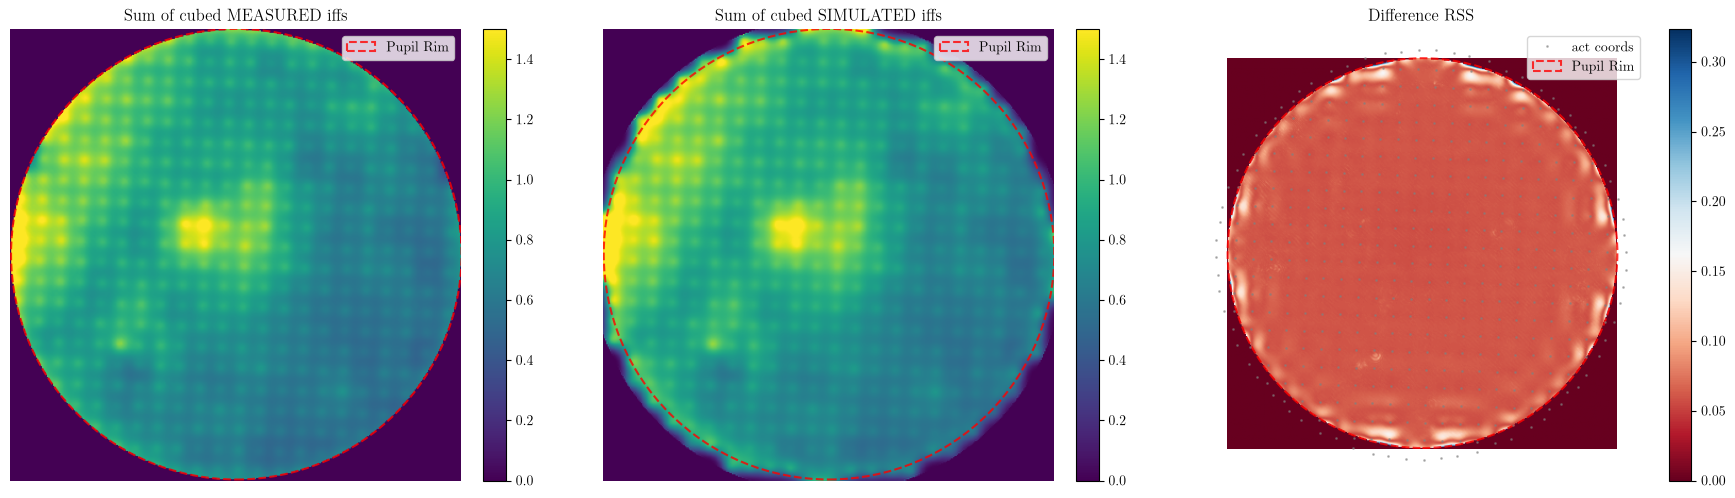

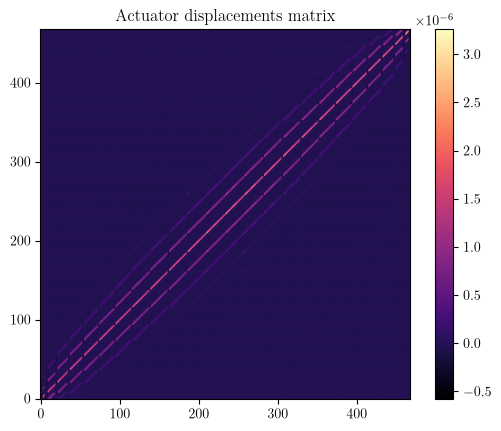

In [10]:
regifs, cmat, coords = register_ao_ifs(meas_ifs2d,meas_mask,sim_ifs2d_flip,sim_mask,optimize_coords=True)

Text(0.5, 1.0, 'Actuator displacements matrix')

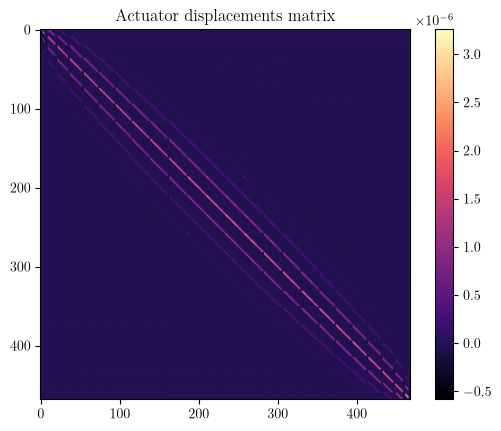

In [11]:
plt.figure()
plt.imshow(cmat,cmap='magma',origin='upper')
plt.colorbar()
plt.title('Actuator displacements matrix')

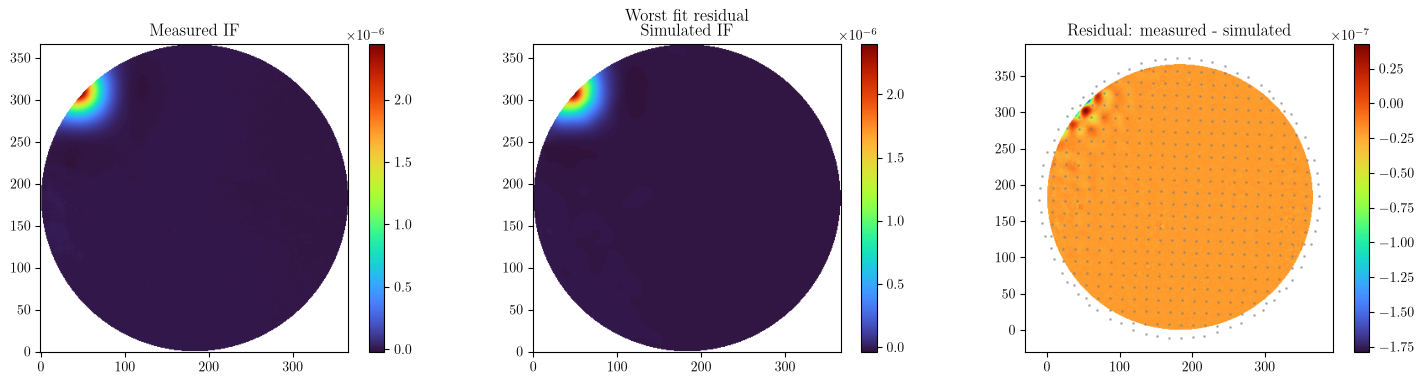

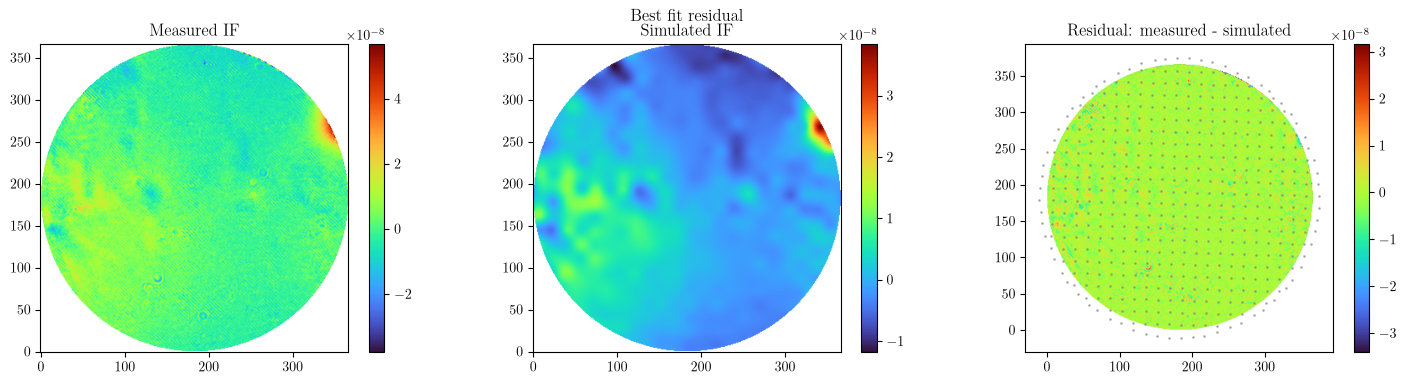

In [12]:
idx = 200
idx = np.argmax(np.sum((regifs-meas_ifs2d)**2,axis=(1,2)))

plt.figure(figsize=(18,4))
plt.subplot(1,3,1)
plt.imshow(np.ma.masked_array(meas_ifs2d[idx],mask=(1-meas_mask)),cmap='turbo',origin='lower')
plt.colorbar()
plt.title('\nMeasured IF')
plt.subplot(1,3,2)
plt.imshow(np.ma.masked_array(regifs[idx],mask=(1-meas_mask)),cmap='turbo',origin='lower')
plt.colorbar()
plt.title('Worst fit residual\nSimulated IF')
plt.subplot(1,3,3)
plt.imshow(np.ma.masked_array(regifs[idx]-meas_ifs2d[idx],mask=(1-meas_mask)),cmap='turbo',origin='lower')
plt.plot(coords[:,1],coords[:,0],'.',markersize=2,c='gray',alpha=0.5)
plt.title('\nResidual: measured - simulated')
plt.colorbar()


idx = np.argmin(np.sum((regifs-meas_ifs2d)**2,axis=(1,2)))
plt.figure(figsize=(18,4))
plt.subplot(1,3,1)
plt.imshow(np.ma.masked_array(meas_ifs2d[idx],mask=(1-meas_mask)),cmap='turbo',origin='lower')
plt.colorbar()
plt.title('\nMeasured IF')
plt.subplot(1,3,2)
plt.imshow(np.ma.masked_array(regifs[idx],mask=(1-meas_mask)),cmap='turbo',origin='lower')
plt.colorbar()
plt.title('Best fit residual\nSimulated IF')
plt.subplot(1,3,3)
plt.imshow(np.ma.masked_array(regifs[idx]-meas_ifs2d[idx],mask=(1-meas_mask)),cmap='turbo',origin='lower')
plt.plot(coords[:,1],coords[:,0],'.',markersize=2,c='gray',alpha=0.5)
plt.title('\nResidual: measured - simulated')
plt.colorbar()



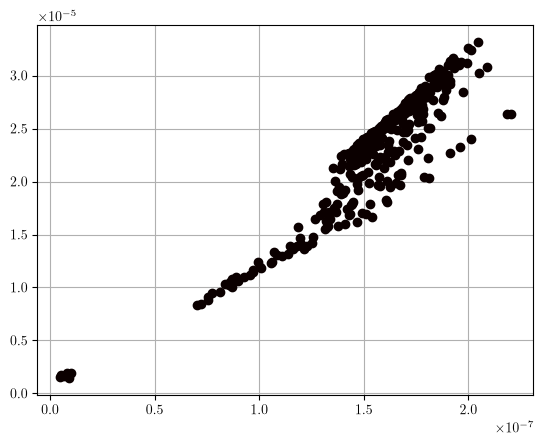

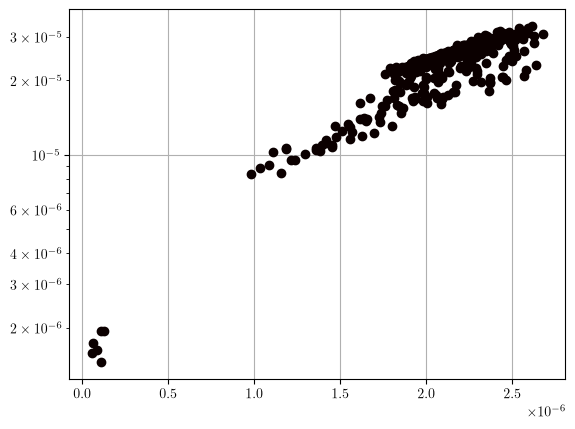

In [13]:
plt.figure()
plt.plot(np.sqrt(np.mean(cmat**2,axis=1)),np.sum(abs(cmat),axis=1),'o')
plt.grid()

plt.figure()
plt.semilogy(np.max(np.abs(meas_ifs2d),axis=(1,2)),np.sum(abs(cmat),axis=1),'o')
plt.grid()


<Figure size 640x480 with 0 Axes>

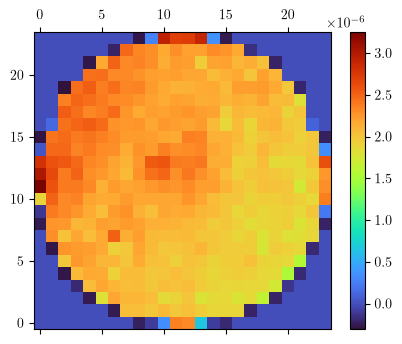

In [14]:
cdiag = np.diag(cmat)
if len(cdiag) == 468:
    dmMap = np.array([
        [0,0,0,0,0,0,0,0,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0],
        [0,0,0,0,0,0,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0],
        [0,0,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0],
        [0,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0],
        [0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0],
        [0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0],
        [0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0],
        [0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0],
        [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
        [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
        [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
        [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
        [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
        [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
        [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
        [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
        [0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0],
        [0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0],
        [0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0],
        [0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0],
        [0,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0],
        [0,0,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0],
        [0,0,0,0,0,0,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0],
        [0,0,0,0,0,0,0,0,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0]
    ])
elif len(cdiag) == 820:
    dmMap = np.array([
            [0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0],
            [0,0,0,0,0,0,0,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0],
            [0,0,0,0,0,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0],
            [0,0,0,0,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0],
            [0,0,0,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0],
            [0,0,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0],
            [0,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0],
            [0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0],
            [0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0],
            [0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0],
            [0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0],
            [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
            [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
            [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
            [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
            [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
            [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
            [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
            [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
            [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
            [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
            [0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0],
            [0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0],
            [0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0],
            [0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0],
            [0,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0],
            [0,0,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0],
            [0,0,0,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0],
            [0,0,0,0,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0],
            [0,0,0,0,0,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0],
            [0,0,0,0,0,0,0,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0],
            [0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0],
        ])
else:
    raise ValueError()

cdiag2d = np.zeros(dmMap.size)
cdiag2d[dmMap.astype(bool).flatten()] = cdiag
cdiag2d = cdiag2d.reshape(dmMap.shape)

plt.figure()
plt.matshow(cdiag2d,origin='lower',cmap='turbo')
plt.colorbar(shrink=0.8)

43 92


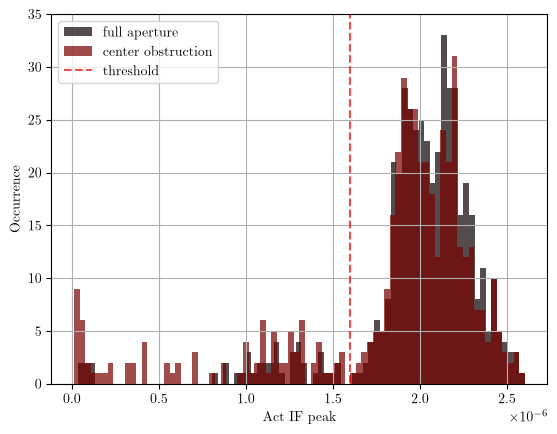

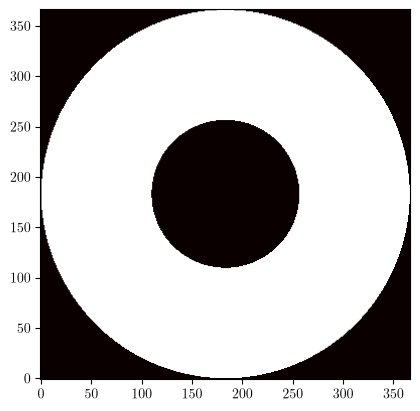

In [52]:
nActs = 468
act_rms = np.zeros([nActs])
act_obs_rms = np.zeros([nActs])

x,y = np.meshgrid(np.linspace(0,meas_mask.shape[0]-1,meas_mask.shape[0]),np.linspace(0,meas_mask.shape[1]-1,meas_mask.shape[1]))
xc = np.sum(meas_mask*x)/np.sum(meas_mask)
yc = np.sum(meas_mask*y)/np.sum(meas_mask)
rho = np.sqrt((x-xc)**2+(y-yc)**2)
centerobs = rho >= 367*0.2
obs_mask = np.logical_and(meas_mask,centerobs)

for j in range(nActs):
    img = regifs[j][meas_mask.astype(bool)]
    img_obs = regifs[j][obs_mask.astype(bool)]
    act_rms[j] = np.max(abs(img))-np.median(abs(img)) #np.sqrt(np.sum(img**2)) # 
    act_obs_rms[j] = np.max(abs(img_obs))-np.median(abs(img_obs)) #np.sqrt(np.sum(img_obs**2)) #

thr = 1.6e-6
print(np.sum(act_rms<thr),np.sum(act_obs_rms<thr))

plt.figure()
plt.hist(act_rms,bins=80,alpha=0.7,label='full aperture')
plt.hist(act_obs_rms,bins=80,alpha=0.7,label='center obstruction')
plt.plot([thr,thr],[-1,50],'--',alpha=0.7,label='threshold')
plt.legend()
plt.ylabel('Occurrence')
plt.xlabel('Act IF peak')
plt.ylim([0,35])
plt.grid()

plt.figure()
plt.imshow(obs_mask)

In [15]:
stop

NameError: name 'stop' is not defined

In [ ]:
from specula.data_objects.m2c import M2C
from specula.lib.modal_base_generator import make_modal_base_from_ifs_fft

In [ ]:
# from specula.lib.make_mask import make_mask
# obs_mask = make_mask(np_size=np.max(meas_mask.shape),diaratio=0.98,obsratio=0.32)
# obs_mask_int = np.logical_and(obs_mask.astype(bool),meas_mask)


# plt.figure(figsize=(18,4))
# plt.subplot(1,3,1)
# plt.imshow(obs_mask,cmap='grey',origin='lower')
# plt.subplot(1,3,2)
# plt.imshow(meas_mask,cmap='grey',origin='lower')
# plt.subplot(1,3,3)
# plt.imshow(obs_mask_int,cmap='grey',origin='lower')

# fits.writeto('/raid1/mmenessini/calibration/EKARUS/data/repaired_mask.fits',meas_mask.astype(np.uint8),overwrite=True)
# fits.writeto('/raid1/mmenessini/calibration/EKARUS/data/repaired_mask_centerobs.fits',obs_mask_int.astype(np.uint8),overwrite=True)

In [ ]:
iffs = np.zeros([len(regifs),np.sum(meas_mask)])
for i in range(len(regifs)):
    iffs[i,:] = (regifs[i][meas_mask]).flatten()

if_obj = IFunc(ifunc=iffs,mask=meas_mask.astype(np.uint8))
if_obj.save('/raid1/mmenessini/calibration/EKARUS/ifunc/repaired_iffs.fits',overwrite=True)
fits.writeto('/raid1/mmenessini/calibration/EKARUS/data/repaired_iffs.fits',iffs,overwrite=True)

# obs_iffs = np.zeros([len(regifs),np.sum(obs_mask_int)])
# for i in range(len(regifs)):
#     obs_iffs[i,:] = (regifs[i][obs_mask_int.astype(bool)]).flatten()

# if_obs_obj = IFunc(ifunc=obs_iffs,mask=obs_mask_int.astype(np.uint8))
# if_obs_obj.save('/raid1/mmenessini/calibration/EKARUS/ifunc/repaired_iffs_centerobs.fits',overwrite=True)

In [ ]:
zern_modes = 2
oversampling = 4
# r0 = 0.05
# D = 1.82
r0 = 0.1
D = 8.0
L0 = 25
rCond = 1e+4

kl_basis, m2c, _ = make_modal_base_from_ifs_fft(
    pupil_mask=specula.xp.array(meas_mask),
    diameter=D,
    influence_functions=specula.xp.array(iffs),
    r0=r0,
    L0=L0,
    zern_modes=zern_modes,
    oversampling=oversampling,
    if_max_condition_number=rCond,
    xp=specula.xp,
    dtype=specula.xp.float64,
)

m2c_obj = M2C(m2c=m2c)
m2c_obj.save('/raid1/mmenessini/calibration/EKARUS/m2c/repaired_m2c.fits', overwrite=True)

# kl_basis_obs, m2c_obs, _ = make_modal_base_from_ifs_fft(
#     pupil_mask=specula.xp.array(obs_mask_int),
#     diameter=D,
#     influence_functions=specula.xp.array(obs_iffs),
#     r0=r0,
#     L0=L0,
#     zern_modes=zern_modes,
#     oversampling=oversampling,
#     if_max_condition_number=rCond,
#     xp=specula.xp,
#     dtype=specula.xp.float64,
# )

# m2c_obs_obj = M2C(m2c=m2c_obs)
# m2c_obs_obj.save('/raid1/mmenessini/calibration/EKARUS/m2c/repaired_m2c_centerobs.fits', overwrite=True)

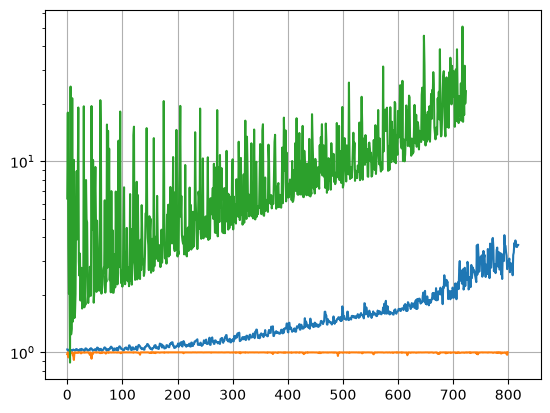

In [ ]:
m2c_ref = fits.getdata('/raid1/mmenessini/calibration/SOUL/m2c/M2C_20260909_091942.fits')
m2c_ref_old = fits.getdata('/raid1/mmenessini/calibration/SOUL/m2c/M2C_20260908_175133.fits')

scale = 1e-5

plt.figure()
plt.semilogy(np.std(m2c_ref,axis=0))
plt.semilogy(np.std(m2c_ref_old,axis=0))
plt.semilogy(np.std(m2c.get()*scale,axis=0))
plt.grid()

# np.save('/raid1/mmenessini/calibration/EKARUS/data/M2C_KL_SPECULA.npy',(m2c.get()*scale).astype(np.float32))

In [ ]:
# m2c_ref = np.load('/raid1/mmenessini/calibration/EKARUS/data/M2C_KL_OOPAO_synthetic.npy')
# m2c_obs_ref = np.load('/raid1/mmenessini/calibration/EKARUS/data/M2C_KL_OOPAO_central_obstruction.npy')

# scale = 5e-7

# plt.figure()
# plt.semilogy(np.std(m2c_ref,axis=0))
# plt.semilogy(np.std(m2c_obs_ref,axis=0))
# plt.semilogy(np.std(m2c.get()*scale,axis=0))
# plt.semilogy(np.std(m2c_obs.get()*scale,axis=0))
# plt.grid()

# # np.save('/raid1/mmenessini/calibration/EKARUS/data/M2C_KL_SPECULA.npy',(m2c.get()*scale).astype(np.float32))
# # np.save('/raid1/mmenessini/calibration/EKARUS/data/M2C_KL_SPECULA_central_obstruction.npy',(m2c_obs.get()*scale).astype(np.float32))